# Running and AI: Intelligent marathon race results prediction

In [1]:
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# About the dataset 

The original dataset contains 10,703,690 records of running training during 2019 and 2020, from 36,412 athletes from around the world. The records were obtained through web scraping of a large social network for athletes on the internet.

The data with the athletes' activities are contained in dataframe objects (tabular data) and saved in the Parquet file format using the Pandas library, part of the Python ecosystem for data science. Each Pandas dataframe contains the following data (as different columns) for each athlete (as different rows), the first word identifies the name of the column in the dataframe:

* datetime: date of the running activity;
* athlete: a computer-generated ID for the athlete (integer);
* distance: distance of running (floating-point number, in kilometers);
* duration: duration of running (floating-point number, in minutes);
* gender: gender (string 'M' of 'F');
* age_group: age interval (one of the strings '18 - 34', '35 - 54', or '55 +');
* country: country of origin of the athlete (string);
* major: marathon(s) and year(s) the athlete ran (comma-separated list of strings).

Originally, the dataset was created for worldwide comparison of long-distance running training in 2019 and 2020: associated effects of the COVID-19 pandemic. 

All informations about gathering and preprociessing the data is available here:

Afonseca LA, Watanabe RN, Duarte M. 2022. A worldwide comparison of long-distance running training in 2019 and 2020: associated effects of the COVID-19 pandemic. PeerJ 10:e13192 https://doi.org/10.7717/peerj.13192

As the goal of our project is to make marathon race times predictions based on training sessions data, we will need to perform some data preprocessing and extract important information. 

## Merging the datasets

In this step, we begin by loading two datasets. These datasets contain training session data for athletes from 2020 and 2019, respectively.

Next, we inspect the beginning of the 2019 dataset using .head() to get a quick overview of its structure.

In [2]:
import os

df_2020 = pd.read_csv(os.path.join('..','..','data','long_distance','run_ww_2020_d.csv')) 
df_2019 = pd.read_csv(os.path.join('..','..','data','long_distance','run_ww_2019_d.csv'))

df_2019.head()

,Unnamed: 0,datetime,athlete,distance,duration,gender,age_group,country,major
0,0,2019-01-01,0,0.00,0.00,F,18 - 34,United States,CHICAGO 2019
1,1,2019-01-01,1,5.27,30.20,M,35 - 54,Germany,BERLIN 2016
2,2,2019-01-01,2,0.00,0.00,M,35 - 54,United Kingdom,"LONDON 2018,LONDON 2019"
3,3,2019-01-01,3,10.50,43.95,M,18 - 34,United Kingdom,LONDON 2017
4,4,2019-01-01,4,9.66,48.65,M,35 - 54,United States,BOSTON 2017


Then, we perform a consistency check on athlete IDs in the 2019 dataset. 
Here’s what each line does:

* **last_athlete_id**: gets the highest athlete ID in the dataset.
* **all_possible_ids**: creates a full set of IDs from 0 to the maximum observed ID.
* **existing_ids**: extracts the actual unique athlete IDs present in the data.
* **missing_ids**: identifies any gaps—i.e., number of athlete IDs that are missing from the expected full range.

As the missing IDs count is not very big, compraing to all athletes count, I decided to simply shift the IDs by the largest one

In [3]:
last_athlete_id = df_2019['athlete'].max()
all_possible_ids = set(range(last_athlete_id + 1))
existing_ids = set(df_2019['athlete'].unique())
missing_ids = sorted(list(all_possible_ids - existing_ids))
print("Missing ids: ", len(missing_ids))
print("Athletes count: ", len(existing_ids))

Missing ids:  1187
Athletes count:  36412


In [4]:
df_2020.head()

,Unnamed: 0,datetime,athlete,distance,duration,gender,age_group,country,major
0,0,2020-01-01,0,0.00,0.000000,F,18 - 34,United States,CHICAGO 2019
1,1,2020-01-01,1,5.72,31.633333,M,35 - 54,Germany,BERLIN 2016
2,2,2020-01-01,2,0.00,0.000000,M,35 - 54,United Kingdom,"LONDON 2018,LONDON 2019"
3,3,2020-01-01,3,0.00,0.000000,M,18 - 34,United Kingdom,LONDON 2017
4,4,2020-01-01,4,8.07,38.616667,M,35 - 54,United States,BOSTON 2017


In [5]:
df_2020['athlete'] = df_2020['athlete'] + last_athlete_id + 1
df_2020.head()

,Unnamed: 0,datetime,athlete,distance,duration,gender,age_group,country,major
0,0,2020-01-01,37599,0.00,0.000000,F,18 - 34,United States,CHICAGO 2019
1,1,2020-01-01,37600,5.72,31.633333,M,35 - 54,Germany,BERLIN 2016
2,2,2020-01-01,37601,0.00,0.000000,M,35 - 54,United Kingdom,"LONDON 2018,LONDON 2019"
3,3,2020-01-01,37602,0.00,0.000000,M,18 - 34,United Kingdom,LONDON 2017
4,4,2020-01-01,37603,8.07,38.616667,M,35 - 54,United States,BOSTON 2017


Finally, we perform sanity check if any of the ids appears in both datasets - the answer is no, the IDs are unique!

In [6]:
athletes_2019 = set(df_2019['athlete'].unique())
athletes_2020 = set(df_2020['athlete'].unique())
common_ids = athletes_2019 & athletes_2020
print("Not unique ids: ", list(common_ids))

Not unique ids:  []


In [7]:
df = pd.concat([df_2019, df_2020], ignore_index=True)
df.tail()

,Unnamed: 0,datetime,athlete,distance,duration,gender,age_group,country,major
26617167,13326787,2020-12-31,75193,20.00,79.0,M,18 - 34,United Kingdom,BERLIN 2017
26617168,13326788,2020-12-31,75194,0.00,0.0,M,18 - 34,United States,"BERLIN 2019,NEW YORK 2015"
26617169,13326789,2020-12-31,75195,25.76,108.0,M,18 - 34,United States,BOSTON 2017
26617170,13326790,2020-12-31,75196,0.00,0.0,F,18 - 34,United States,BOSTON 2015
26617171,13326791,2020-12-31,75197,10.62,71.0,M,35 - 54,China,TOKYO 2012


In [8]:
unique_athletes = df['athlete'].nunique()
print(unique_athletes)

72824


The datasets are merged - now we have one dataset for 72842 athletes. Next, let's check in which marathons did our athletes participate. 

## Extracting and Exploring Marathon Participation (Majors)

The following steps aim to identify and analyze major marathon events that runners participated in during 2019 and 2020. This is useful for filtering the dataset down to athletes who actually competed in major races — a key step for training a prediction model based on real performance outcomes.

In [ ]:
from itertools import chain

unique_majors = set(
    m.strip()
    for sublist in df['major'].dropna().str.split(',')
    for m in sublist
)

print(sorted(unique_majors))

['BERLIN 2009', 'BERLIN 2010', 'BERLIN 2011', 'BERLIN 2012', 'BERLIN 2013', 'BERLIN 2014', 'BERLIN 2015', 'BERLIN 2016', 'BERLIN 2017', 'BERLIN 2018', 'BERLIN 2019', 'BOSTON 2005', 'BOSTON 2008', 'BOSTON 2009', 'BOSTON 2010', 'BOSTON 2011', 'BOSTON 2012', 'BOSTON 2013', 'BOSTON 2014', 'BOSTON 2015', 'BOSTON 2016', 'BOSTON 2017', 'BOSTON 2018', 'BOSTON 2019', 'BOSTON 2020', 'CHICAGO 2009', 'CHICAGO 2010', 'CHICAGO 2011', 'CHICAGO 2012', 'CHICAGO 2013', 'CHICAGO 2014', 'CHICAGO 2015', 'CHICAGO 2016', 'CHICAGO 2017', 'CHICAGO 2018', 'CHICAGO 2019', 'LONDON 2015', 'LONDON 2016', 'LONDON 2017', 'LONDON 2018', 'LONDON 2019', 'NEW YORK 2009', 'NEW YORK 2010', 'NEW YORK 2011', 'NEW YORK 2013', 'NEW YORK 2014', 'NEW YORK 2015', 'NEW YORK 2016', 'NEW YORK 2017', 'NEW YORK 2018', 'NEW YORK 2019', 'TOKYO 2008', 'TOKYO 2011', 'TOKYO 2012', 'TOKYO 2013', 'TOKYO 2014', 'TOKYO 2015', 'TOKYO 2016', 'TOKYO 2017', 'TOKYO 2018', 'TOKYO 2019', 'TOKYO 2020']


As our goal is to predict marathon result based on training sessions data, the only valuable marathons for us are the ones that took place in 2019 or 2020. Therefore, we will filter only those rows that contain 2020 or 2019 race in major colum. 

In [10]:
df_filtered = df[df['major'].str.contains('2019|2020', na=False)]
df_filtered

,Unnamed: 0,datetime,athlete,distance,duration,gender,age_group,country,major
0,0,2019-01-01,0,0.00,0.000000,F,18 - 34,United States,CHICAGO 2019
2,2,2019-01-01,2,0.00,0.000000,M,35 - 54,United Kingdom,"LONDON 2018,LONDON 2019"
8,8,2019-01-01,8,9.99,57.266667,M,35 - 54,United Kingdom,LONDON 2019
12,12,2019-01-01,12,8.76,47.566667,M,35 - 54,United Kingdom,LONDON 2019
13,13,2019-01-01,13,0.00,0.000000,M,35 - 54,United Kingdom,LONDON 2019
...,...,...,...,...,...,...,...,...,...
26617147,13326767,2020-12-31,75173,15.77,79.000000,F,18 - 34,United States,BOSTON 2019
26617150,13326770,2020-12-31,75176,44.43,347.183333,M,35 - 54,United States,"BERLIN 2016,BOSTON 2015,BOSTON 2019"
26617163,13326783,2020-12-31,75189,9.67,58.516667,M,35 - 54,United States,BOSTON 2019
26617166,13326786,2020-12-31,75192,9.90,45.616667,M,18 - 34,United States,NEW YORK 2019


In [11]:
unique_majors = set(
    m.strip()
    for sublist in df_filtered['major'].dropna().str.split(',')
    for m in sublist
)

print(sorted(unique_majors)) 

['BERLIN 2012', 'BERLIN 2013', 'BERLIN 2014', 'BERLIN 2015', 'BERLIN 2016', 'BERLIN 2017', 'BERLIN 2018', 'BERLIN 2019', 'BOSTON 2008', 'BOSTON 2009', 'BOSTON 2010', 'BOSTON 2011', 'BOSTON 2012', 'BOSTON 2013', 'BOSTON 2014', 'BOSTON 2015', 'BOSTON 2016', 'BOSTON 2017', 'BOSTON 2018', 'BOSTON 2019', 'BOSTON 2020', 'CHICAGO 2011', 'CHICAGO 2012', 'CHICAGO 2013', 'CHICAGO 2014', 'CHICAGO 2015', 'CHICAGO 2016', 'CHICAGO 2017', 'CHICAGO 2018', 'CHICAGO 2019', 'LONDON 2015', 'LONDON 2016', 'LONDON 2017', 'LONDON 2018', 'LONDON 2019', 'NEW YORK 2013', 'NEW YORK 2014', 'NEW YORK 2015', 'NEW YORK 2016', 'NEW YORK 2017', 'NEW YORK 2018', 'NEW YORK 2019', 'TOKYO 2012', 'TOKYO 2013', 'TOKYO 2014', 'TOKYO 2015', 'TOKYO 2016', 'TOKYO 2017', 'TOKYO 2018', 'TOKYO 2019', 'TOKYO 2020']


The marathons that are particularly important for us are the ones from 2019 and 2020. Let's see how many such marathons do we have in out dataset. 

In [12]:
all_majors = df_filtered['major'].str.split(',').explode()
majors_19_20 = all_majors[all_majors.str.contains('2019|2020')].unique()

# Marathons from 2019 or 2020
print("Marathons in 2019 and 2020:")
for major in sorted(majors_19_20):
    print(major)

Marathons in 2019 and 2020:
BERLIN 2019
BOSTON 2019
BOSTON 2020
CHICAGO 2019
LONDON 2019
NEW YORK 2019
TOKYO 2019
TOKYO 2020


During data collection, the athletes data were anonymized so unfortunately we cannot simply check the athlete result in marathon results sheet. However, knowing the marathon date we will be able to extract most of the race results from our dataset. This dictionary links marathon names to their actual calendar dates.
This is essential for:
* Time-based filtering,
* Training sequence models leading up to the race,
* Evaluating performance relative to training windows.

In [13]:
marathon_to_date = {
    'BERLIN 2019':'2019-09-29',
    'BOSTON 2019':'2019-04-15',
    'CHICAGO 2019':'2019-10-13',
    'LONDON 2019':'2019-04-28',
    'NEW YORK 2019':'2019-11-03',
    'TOKYO 2019':'2019-03-03',
    'TOKYO 2020':'2020-03-01', 
    'BOSTON 2020':'2020-09-14',
}

## Extracting race results 

To extract race results data from our dataset, we will perform filtering. The conditions for the activity to be marked as a marathon race are the following:
* the data in 'datetime' and 'major' columns may not be missing
* the date of the activity has to match one of the marathons' dates
* the distance of the activity has to be greater than 42k
* the marathon name matching the date needs to be present in major column 

In [14]:
# from collections import defaultdict

# Convert all dates in the datetime column and the marathon_to_date dictionary to a consistent YYYY-MM-DD format
df_filtered.loc[:, 'datetime'] = pd.to_datetime(df_filtered['datetime'], errors='coerce').dt.strftime('%Y-%m-%d')
marathon_to_date = {name: pd.to_datetime(date).strftime('%Y-%m-%d') for name, date in marathon_to_date.items()}
    
# Create a set of all marathon dates for fast lookup
marathon_dates = set(marathon_to_date.values())

def match_row(row):
    if (
        pd.isna(row['datetime']) or 
        pd.isna(row['major']) or
        row['distance'] <= 42 or
        row['datetime'] not in marathon_dates
    ):
        return False
    major_list = [m.strip() for m in row['major'].split(',')]
    return any(marathon_to_date.get(m) == row['datetime'] for m in major_list)

# Test the function
example_row = pd.Series({
    'datetime': '2019-04-28',           # matches LONDON 2019
    'athlete': 'John Doe',
    'distance': 42.5,                   # > 42 km
    'duration': '03:15:00',
    'gender': 'M',
    'age_group': '30-39',
    'country': 'UK',
    'major': 'LONDON 2019,CHICAGO 2020' # includes LONDON 2019
})
match_row(example_row)

True

Next, we use previously defined match_row function to filter only valid marathon records. We also get the number of distinct athletes who ran at least one marathon. As the number of athletes with more than 1 marathon is relatively small, I decided to use only the last one as a target - it seems reasonable bacause we have the most training activities data leading to this event.

In [15]:
matching_activities = df_filtered[df_filtered.apply(match_row, axis=1)].copy()
athlete_ids = matching_activities['athlete'].unique()
print("Number of athletes with a marathon:",len(athlete_ids))
matching_activities

Number of athletes with a marathon: 15685


,Unnamed: 0,datetime,athlete,distance,duration,gender,age_group,country,major
2221150,2221150,2019-03-03,18,42.77,194.000000,M,35 - 54,Japan,TOKYO 2019
2221153,2221153,2019-03-03,22,44.66,215.000000,M,18 - 34,Belarus,TOKYO 2019
2221170,2221170,2019-03-03,41,43.11,299.000000,M,35 - 54,United Kingdom,"BERLIN 2013,LONDON 2016,TOKYO 2019"
2221193,2221193,2019-03-03,65,43.74,282.000000,M,35 - 54,Brazil,TOKYO 2019
2221320,2221320,2019-03-03,199,43.40,239.000000,M,35 - 54,France,TOKYO 2019
...,...,...,...,...,...,...,...,...,...
11178452,11178452,2019-11-03,37567,42.69,147.000000,F,18 - 34,United States,NEW YORK 2019
11178455,11178455,2019-11-03,37570,43.22,141.050000,M,18 - 34,United States,"BOSTON 2017,NEW YORK 2019"
11178478,11178478,2019-11-03,37593,42.43,136.000000,M,18 - 34,United States,NEW YORK 2019
15502330,2211950,2020-03-01,65623,44.51,179.816667,F,18 - 34,Japan,"BOSTON 2019,TOKYO 2020"


In [16]:
# Count marathons for each athlete
marathon_counts = matching_activities['athlete'].value_counts()

# Filter athletes with multiple marathons
athletes_with_multiple_marathons = marathon_counts[marathon_counts > 1]
athletes_with_multiple_marathons_2 = marathon_counts[marathon_counts > 2]

# Count the athletes with multiple marathons
num_athletes = len(athletes_with_multiple_marathons)
num_athletes_2 = len(athletes_with_multiple_marathons_2)

print("Number of athletes with more than 1 marathon: ", num_athletes)
print("Number of athletes with more than 2 marathons: ", num_athletes_2 )

Number of athletes with more than 1 marathon:  574
Number of athletes with more than 2 marathons:  32


Finally we can extract marathon activities from our dataset. This code scans through the filtered dataset of running sessions and builds a dictionary (athlete_latest_marathon) that stores the most recent marathon (in 2019 or 2020) for each athlete, along with the name of the marathon and the finish time (duration).

In [17]:
# from collections import defaultdict

# Create a new dictionary to store only the latest marathon per athlete
athlete_latest_marathon = {}

for _, row in df_filtered.iterrows():
    if (
        pd.isna(row['datetime']) or 
        pd.isna(row['major']) or
        row['distance'] <= 42 or
        row['datetime'] not in marathon_dates
    ):
        continue

    major_list = [m.strip() for m in row['major'].split(',')]
    
    for m in major_list:
        if marathon_to_date.get(m) == row['datetime']:
            athlete = row['athlete']
            current_m_date = row['datetime']
            current_m_duration = row['duration']

            if athlete not in athlete_latest_marathon:
                athlete_latest_marathon[athlete] = (current_m_date, m, current_m_duration)
            else:
                previous_m_date = athlete_latest_marathon[athlete][0]
                if current_m_date > previous_m_date:
                    athlete_latest_marathon[athlete] = (current_m_date, m, current_m_duration)


After this loop athlete_latest_marathon contains a clean summary of the latest marathon performance per athlete. 

In [18]:
for athlete, (date, marathon, duration) in list(athlete_latest_marathon.items())[:10]:
    print(f"Athlete: {athlete}")
    print(f"{marathon} ({date}): {duration}")
    print()

Athlete: 18
TOKYO 2019 (2019-03-03): 194.0

Athlete: 22
TOKYO 2019 (2019-03-03): 215.0

Athlete: 41
TOKYO 2019 (2019-03-03): 299.0

Athlete: 65
TOKYO 2019 (2019-03-03): 282.0

Athlete: 199
TOKYO 2019 (2019-03-03): 239.0

Athlete: 220
CHICAGO 2019 (2019-10-13): 280.0

Athlete: 265
TOKYO 2019 (2019-03-03): 333.0

Athlete: 284
TOKYO 2019 (2019-03-03): 215.0

Athlete: 307
TOKYO 2019 (2019-03-03): 244.0

Athlete: 318
TOKYO 2019 (2019-03-03): 227.0



## Data Enrichment: Finalizing the Marathon Dataset


In this step, we enrich the dataset by:
1.  Selecting only relevant athletes - We filter the main dataset to include only athletes who were previously identified as having completed at least one marathon in 2019 or 2020
2.  Adding detailed marathon information per athlete (m_date, m_name, m_time)
3. Extracting year data from race records
4.  Counting the number of marathons each athlete participated in - We compute the total number of marathon entries per athlete by counting comma-separated entries in the major field.
This gives us a basic indicator of each athlete’s marathon experience.

This enriched dataset is now well-suited for deeper analysis, such as studying progression trends, experience levels, or preparing training/prediction models.

In [ ]:
import re 

df_final = df[df['athlete'].isin(athlete_ids)]

def get_marathon_info(athlete):
    info = athlete_latest_marathon.get(athlete)
    if info:
        date, name, time = info
        return pd.Series([date, name, time])
    else:
        return pd.Series([None, None, None])


# Extract marathon years from 'major' column
def extract_years(major_string):
    if pd.isna(major_string):
        return []
    return re.findall(r'\b(20\d{2})\b', major_string)


# Add new columns to df_final
df_final[['m_date','m_name', 'm_time']] = df_final['athlete'].apply(get_marathon_info)
df_final['prev_m_years'] = df_final['major'].apply(extract_years)
df_final['prev_m_years'] = df_final['prev_m_years'].apply(lambda x: list(map(int, x)))
df_final['overall_m_count'] = df_final['major'].fillna('').apply(
    lambda x: len([m.strip() for m in x.split(',') if m.strip()])
)


C:\Users\abela\AppData\Local\Temp\ipykernel_19804\2803479440.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final[['m_date','m_name', 'm_time']] = df_final['athlete'].apply(get_marathon_info)
C:\Users\abela\AppData\Local\Temp\ipykernel_19804\2803479440.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final[['m_date','m_name', 'm_time']] = df_final['athlete'].apply(get_marathon_info)
C:\Users\abela\AppData\Local\Temp\ipykernel_19804\2803479440.py:22: SettingWithCopyWarning: 
A value is trying

In [19]:
import re

# 1) Make an explicit copy to avoid view vs copy issues
df_final = df[df['athlete'].isin(athlete_ids)].copy()

def get_marathon_info(athlete):
    info = athlete_latest_marathon.get(athlete)
    if info:
        date, name, time = info
        return pd.Series([date, name, time], index=['m_date','m_name','m_time'])
    else:
        return pd.Series([None, None, None], index=['m_date','m_name','m_time'])

def extract_years(major_string):
    if pd.isna(major_string):
        return []
    return re.findall(r'\b(20\d{2})\b', major_string)

# 2) Assign with .loc to avoid chained assignment
df_final[['m_date','m_name','m_time']] = df_final['athlete'].apply(get_marathon_info)

# 3) Compute prev_m_years as ints
df_final.loc[:, 'prev_m_years'] = df_final['major'].apply(extract_years).apply(lambda x: list(map(int, x)))

# 4) Overall count (robust to NaN and stray commas)
df_final.loc[:, 'overall_m_count'] = (
    df_final['major'].fillna('')
    .apply(lambda x: len([m.strip() for m in x.split(',') if m.strip()]))
)


 ## Final Data Cleaning and Preprocessing

 This section finalizes the preparation of the dataset by removing irrelevant or erroneous records, handling missing values, and ensuring temporal consistency of the data:
 * The column 'major' is dropped because its information has already been extracted and integrated into other fields (prev_m_years, overall_m_count, etc.).
* Rows where the 'distance' is zero or negative are removed — these are likely invalid records or non-activities.
* If present, the column 'Unnamed: 0', often an artifact from CSV file exports, is removed to avoid redundancy.
* Records with marathon times exceeding 420 minutes (7 hours) are removed. These are likely outliers, misreported durations, or non-competitive marathon attempts.
* Missing values in the 'country' field are filled with "Unknown" to preserve the record while indicating uncertainty about the athlete’s origin.
* Only activities recorded before the athlete’s latest marathon date are kept. This ensures that the dataset reflects pre-marathon activities, which is important for any analysis aiming to understand training behavior or performance predictors.

In [20]:
df_final = df_final.drop(columns=['major'])
df_final = df_final[df_final['distance'] > 0]
if 'Unnamed: 0' in df_final.columns:
    df_final.drop(columns=['Unnamed: 0'], inplace=True)


df_final = df_final[df_final['m_time'] < 420]


# Checking for missing values 
# See count of missing values per column
missing = df_final.isnull().sum()
missing = missing[missing > 0]  # Filter to only show columns with missing values

print("Missing values per column:")
print(missing)


df_final['country'] = df_final['country'].fillna('Unknown')

print(df_final['country'].unique().tolist())

# Check for 0s in numeric columns
zero_counts = (df_final == 0).sum(numeric_only=True)
zero_counts = zero_counts[zero_counts > 0]

print("\nZero-value counts per numeric column:")
print(zero_counts)

# Filter: only keep activities before the marathon date
df_final = df_final[df_final["datetime"] < df_final["m_date"]]

df_final.to_csv("df_final.csv", index=False)


Missing values per column:
country    7028
dtype: int64
['United Kingdom', 'United States', 'Norway', 'Spain', 'Taiwan', 'Switzerland', 'Russia', 'Brazil', 'Sweden', 'Germany', 'Austria', 'Poland', 'Netherlands', 'Canada', 'France', 'Japan', 'China', 'South Korea', 'Australia', 'Malaysia', 'Jersey', 'Turkey', 'South Africa', 'Italy', 'Iceland', 'Singapore', 'India', 'Thailand', 'Peru', 'Belarus', 'Costa Rica', 'Belgium', 'Ireland', 'Bolivia', 'United Arab Emirates', 'Guatemala', 'New Zealand', 'Hungary', 'Philippines', 'Kazakhstan', 'Indonesia', 'Kosovo', 'Isle of Man', 'Kenya', 'Latvia', 'Chile', 'Unknown', 'Mexico', 'Argentina', 'Portugal', 'Czechia', 'Panama', 'Denmark', 'Estonia', 'Tunisia', 'Venezuela', 'Greece', 'Ghana', 'Slovenia', 'Ukraine', 'Colombia', 'Cayman Islands', 'Romania', 'Ecuador', 'Finland', 'Faroe Islands', 'Luxembourg', 'Croatia', 'Cyprus', 'Bulgaria', 'Dominican Republic', 'Israel', 'Lithuania', 'Serbia', 'Vietnam', 'Nigeria', 'Bahrain', 'Moldova', 'Slovakia', 'J

## Final dataset

In [21]:
print("Athletes number:", len(df_final['athlete'].unique()))
df_final

Athletes number: 15481


,datetime,athlete,distance,duration,gender,age_group,country,m_date,m_name,m_time,prev_m_years,overall_m_count
8,2019-01-01,8,9.99,57.266667,M,35 - 54,United Kingdom,2019-04-28,LONDON 2019,239.000000,[2019],1
12,2019-01-01,12,8.76,47.566667,M,35 - 54,United Kingdom,2019-04-28,LONDON 2019,218.000000,[2019],1
15,2019-01-01,15,19.49,95.000000,M,35 - 54,United States,2019-04-15,BOSTON 2019,198.000000,"[2017, 2019]",2
27,2019-01-01,29,22.87,105.033333,M,18 - 34,Norway,2019-04-28,LONDON 2019,156.000000,"[2017, 2019]",2
32,2019-01-01,35,24.15,106.000000,M,18 - 34,United States,2019-04-15,BOSTON 2019,173.000000,[2019],1
...,...,...,...,...,...,...,...,...,...,...,...,...
15393094,2020-02-27,65623,7.78,34.583333,F,18 - 34,Japan,2020-03-01,TOKYO 2020,179.816667,"[2019, 2020]",2
15395499,2020-02-27,68084,9.26,42.800000,M,18 - 34,Japan,2020-03-01,TOKYO 2020,137.000000,[2020],1
15431911,2020-02-28,68084,12.85,49.800000,M,18 - 34,Japan,2020-03-01,TOKYO 2020,137.000000,[2020],1
15465918,2020-02-29,65623,5.25,21.516667,F,18 - 34,Japan,2020-03-01,TOKYO 2020,179.816667,"[2019, 2020]",2


# Data analysis 

This section explores the characteristics of athletes who participated in marathons, using visualizations to uncover patterns in duration, gender, age distribution, and country representation.

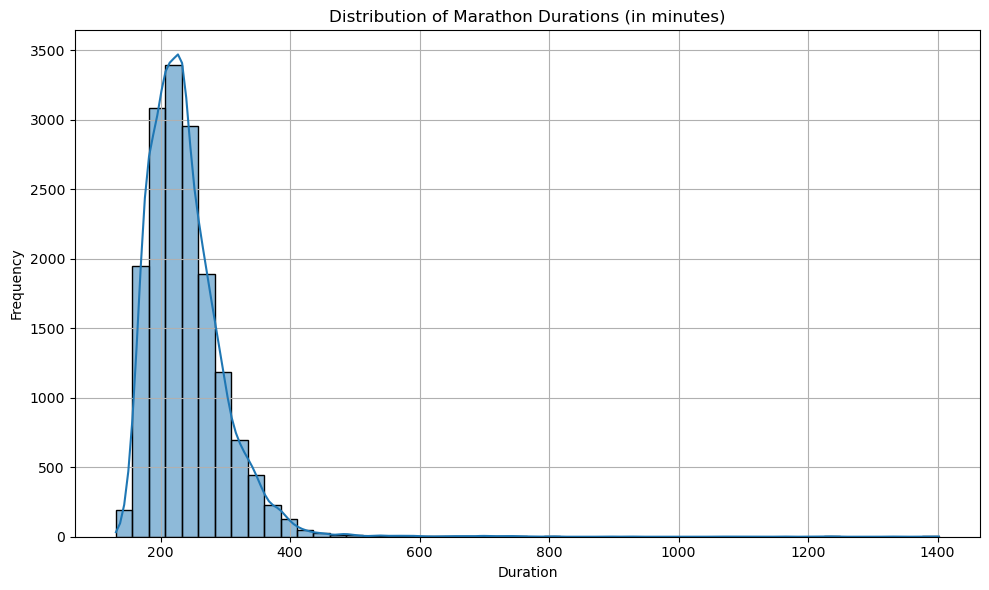

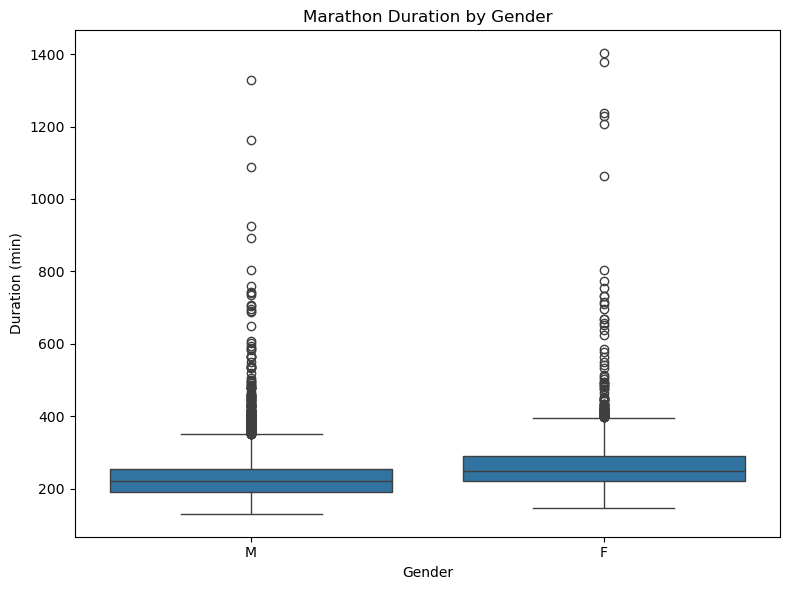

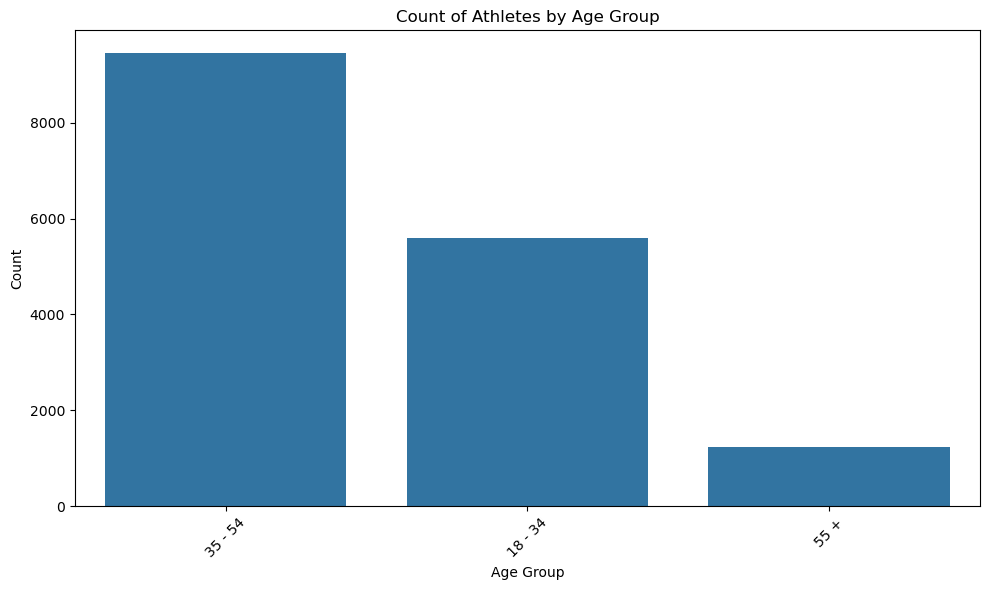

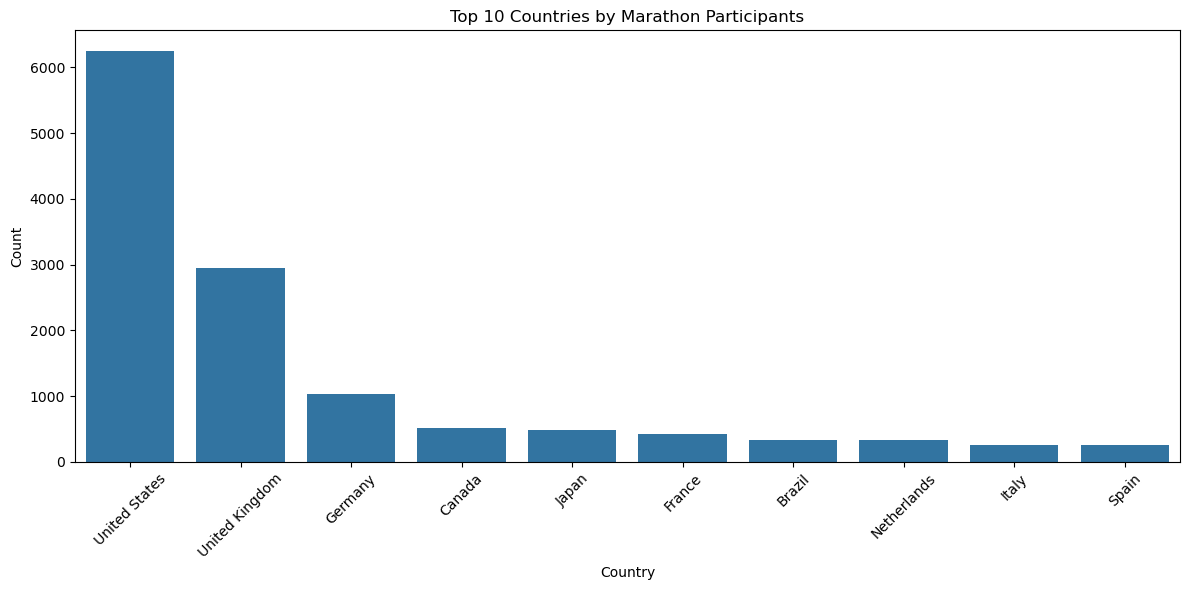

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

ma = matching_activities.copy()

# Overview of dataset
summary = ma.describe(include='all')


# Plot 1: Distribution of marathon durations
plt.figure(figsize=(10, 6))
sns.histplot(ma['duration'], bins=50, kde=True)
plt.title("Distribution of Marathon Durations (in minutes)")
plt.xlabel("Duration")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()

# Plot 2: Average marathon duration by gender
plt.figure(figsize=(8, 6))
sns.boxplot(data=ma, x='gender', y='duration')
plt.title("Marathon Duration by Gender")
plt.xlabel("Gender")
plt.ylabel("Duration (min)")
plt.tight_layout()

# Plot 3: Count of athletes by age group
plt.figure(figsize=(10, 6))
sns.countplot(data=ma, x='age_group', order=ma['age_group'].value_counts().index)
plt.title("Count of Athletes by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()

# Plot 4: Marathon count by country (top 10)
plt.figure(figsize=(12, 6))
top_countries = ma['country'].value_counts().head(10)
sns.barplot(x=top_countries.index, y=top_countries.values)
plt.title("Top 10 Countries by Marathon Participants")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()



## 📈 Plot 1: Distribution of Marathon Durations

This histogram shows the distribution of marathon durations (in minutes) across all recorded activities.

* Most athletes completed marathons within 200 to 300 minutes.
* The distribution appears to be right-skewed
* A small number of outliers with durations over 400 minutes can be observed.

## 👥 Plot 2: Average Marathon Duration by Gender

This boxplot compares marathon durations by gender.

* The median duration for males is approximately 200 minutes, while for females it is around 250 minutes.
* The interquartile range is larger for females, indicating more variation.
* Outliers are also more visible in the female group.

## 📊 Plot 3: Count of Athletes by Age Group

This bar chart shows the number of athletes in each age group.

* The most represented age group is 35-54, followed by 18-35.
* Older age groups (over 55) have significantly fewer participants.
* This suggests that most marathon runners fall within the 30-50 age range.


## 🌍 Plot 4: Marathon Count by Country (Top 10)

This bar chart displays the top 10 countries with the highest number of marathon participants.

* The country with the highest count is USA with over 6000 athletes.
* Other notable countries include UK and Germany.
* This is more of a interesting info about our dataset than an actual tendency, we don't have access to the data of all of the marathons' participants


# Data aggregation 

This section focuses on aggregating and transforming athlete activity data to prepare it for further analysis, i.e. to be put into Linear Regression model. Each athlete’s marathon preparation is grouped and summarized at the level of a single marathon event.

For each athlete-marathon combination, various summary statistics are computed:

* datetime: first and last training session,
* distance: average, total, and count of training sessions,
* duration: average and total duration of training,
* gender, age group, country: extracted from first available record (since they're constant per athlete),
* m_time: official marathon completion time,
* prev_m_years: list of years in which the athlete ran previous majors,
* overall_m_count: total number of known marathons the athlete has completed.

Also new features are derived to better describe the athlete’s marathon preparation:

* total_days: the total number of days between the first and last training session for a marathon.
* avg_pace: the average pace in minutes per kilometer

Each row now represents one athlete preparing for one marathon, with summarised statistics on their training patterns and demographic attributes.

In [ ]:
# Group by athlete + marathon name (m_name) + marathon time

df = pd.read_csv("df_final.csv", parse_dates=["datetime", "m_date"])

# Aggregation function
agg_df = df.groupby(["athlete", "m_date", "m_name"]).agg({
    "datetime": ["min", "max"],
    "distance": ["mean", "sum", "count"],
    "duration": ["mean", "sum"],
    "gender": "first",
    "age_group": "first",
    "country": "first",
    "m_time": "first",  # marathon time — same for all rows in group
    "prev_m_years": "first",
    "overall_m_count": "first"
}).reset_index()

agg_df.columns = ['_'.join(col) for col in agg_df.columns]

# Feature engineering
# Convert datetime columns to actual datetime type
agg_df['datetime_min'] = pd.to_datetime(agg_df['datetime_min'])
agg_df['datetime_max'] = pd.to_datetime(agg_df['datetime_max'])

# Now calculate total days

agg_df['total_days'] = (agg_df['datetime_max'] - agg_df['datetime_min']).dt.days + 1
agg_df['avg_pace'] = agg_df['duration_sum'] / agg_df['distance_sum']

agg_df.rename(columns={
    "m_date_":"m_date",
    "athlete_":"athlete",
    "gender_first": "gender",
    "age_group_first": "age_group",
    "country_first": "country",
    "m_time_first": "m_time",
    "prev_m_years_first": "prev_m_years",
    "overall_m_count_first": "overall_m_count"
}, inplace=True)


agg_df.to_csv("df_aggregated.csv", index=False)
agg_df

,athlete,m_date,m_name_,datetime_min,datetime_max,distance_mean,distance_sum,distance_count,duration_mean,duration_sum,gender,age_group,country,m_time,prev_m_years,overall_m_count,total_days,avg_pace
0,0,2019-10-13,CHICAGO 2019,2019-06-03,2019-10-12,10.490000,555.970,53,64.159119,3400.433333,F,18 - 34,United States,283.000000,[2019],1,132,6.116217
1,2,2019-04-28,LONDON 2019,2019-01-05,2019-04-25,11.847617,710.857,60,67.079444,4024.766667,M,35 - 54,United Kingdom,237.000000,"[2018, 2019]",2,111,5.661851
2,8,2019-04-28,LONDON 2019,2019-01-01,2019-04-27,11.192130,514.838,46,64.823913,2981.900000,M,35 - 54,United Kingdom,239.000000,[2019],1,117,5.791919
3,12,2019-04-28,LONDON 2019,2019-01-01,2019-04-13,16.233603,941.549,58,86.204023,4999.833333,M,35 - 54,United Kingdom,218.000000,[2019],1,103,5.310221
4,13,2019-04-28,LONDON 2019,2019-01-05,2019-04-21,14.749694,530.989,36,77.946759,2806.083333,M,35 - 54,United Kingdom,226.000000,[2019],1,107,5.284636
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15476,37590,2019-04-15,BOSTON 2019,2019-01-01,2019-04-14,17.357293,1301.797,75,91.918667,6893.900000,M,35 - 54,United States,208.000000,[2019],1,104,5.295680
15477,37593,2019-11-03,NEW YORK 2019,2019-01-01,2019-11-02,23.145108,6434.340,278,94.933933,26391.633333,M,18 - 34,United States,136.000000,[2019],1,306,4.101685
15478,37595,2019-09-29,BERLIN 2019,2019-01-01,2019-09-28,18.517599,4759.023,257,77.187743,19837.250000,M,18 - 34,United States,146.266667,"[2019, 2015]",2,271,4.168345
15479,65623,2020-03-01,TOKYO 2020,2020-01-03,2020-02-29,13.872079,527.139,38,65.978070,2507.166667,F,18 - 34,Japan,179.816667,"[2019, 2020]",2,58,4.756178


# Baseline models

Finally, we can build and evaluate a baseline predictive model aiming to estimate an athlete's marathon finish time (m_time) based on features derived from their training and demographic profile.

### Feature Selection
The following variables were chosen as predictors of marathon time:

* distance_sum: Total distance trained before the marathon
* duration_sum: Total duration of training (in minutes)
* overall_m_count: Total number of known previous marathons
* total_days: Length of the preparation period
* gender, age_group, country: Categorical demographic features
  
The target variable is:
* m_time: Marathon completion time (in minutes)

Any rows with missing marathon time are dropped. Categorical features (gender, age_group, country) are one-hot encoded using pd.get_dummies(). We use a simple Linear Regression model as a baseline, providing an interpretable benchmark for future, more complex models.


### Evaluation
The model is evaluated on the test set using common regression metrics:
* MAE (Mean Absolute Error) gives the average prediction error in minutes.
* RMSE (Root Mean Squared Error) penalizes large errors more strongly.
* NRMSE (Normalized RMSE) expresses error relative to the range of target values.

## 1. Linear Regression


MAE: 27.98 minutes
RMSE: 36.76 minutes
NRMSE: 0.1277


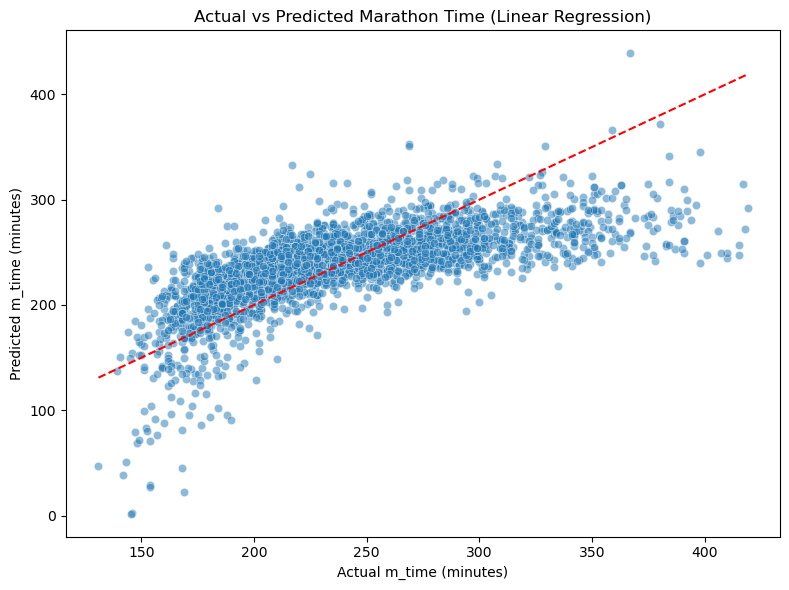

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
from matplotlib import pyplot as plt
import seaborn as sns

agg_df = pd.read_csv('df_aggregated.csv')

# --- Features to use ---
features = [
    'distance_sum',
    'duration_sum',
    'overall_m_count',
    'total_days',
    'gender',
    'age_group',
    'country'
]
target = 'm_time'  

# --- Drop rows with missing target ---
agg_df = agg_df.dropna(subset=[target])

# --- Encode categorical features ---
X = pd.get_dummies(agg_df[features])
y = agg_df[target]

# --- Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Train a Random Forest model ---
model = LinearRegression()
model.fit(X_train, y_train)

# --- Predictions ---
y_pred = model.predict(X_test)

# --- Evaluation ---

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
nrmse = rmse / (y_test.max() - y_test.min())

print(f"MAE: {mae:.2f} minutes")
print(f"RMSE: {rmse:.2f} minutes")
print(f"NRMSE: {nrmse:.4f}")

# --- Plot Actual vs Predicted ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual m_time (minutes)')
plt.ylabel('Predicted m_time (minutes)')
plt.title('Actual vs Predicted Marathon Time (Linear Regression)')
plt.tight_layout()
plt.show()


## 2. Random Forest Regression
This model uses a tree-based ensemble method to predict marathon finish times (m_time) based on training metrics and demographic features, similarly as in LR model. 

MAE: 21.84 minutes
RMSE: 30.15 minutes
NRMSE: 12.7276%
R² Score: 0.64


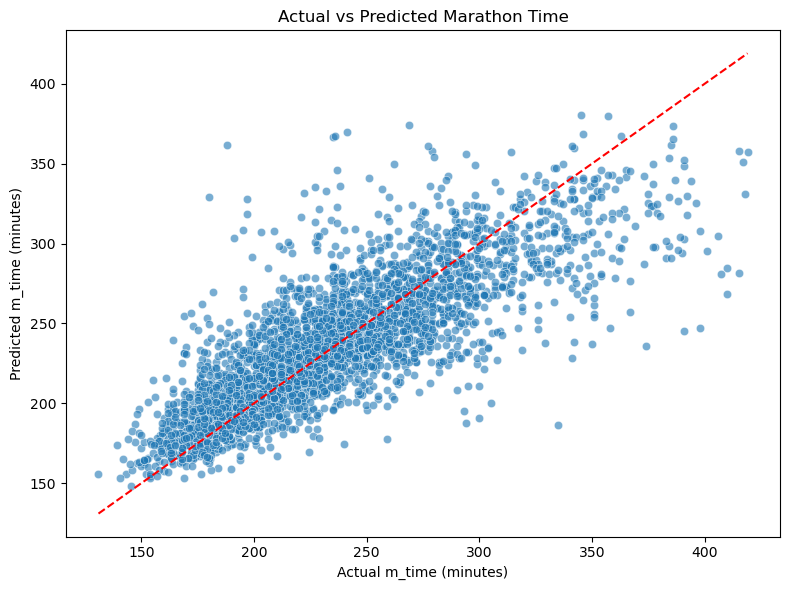

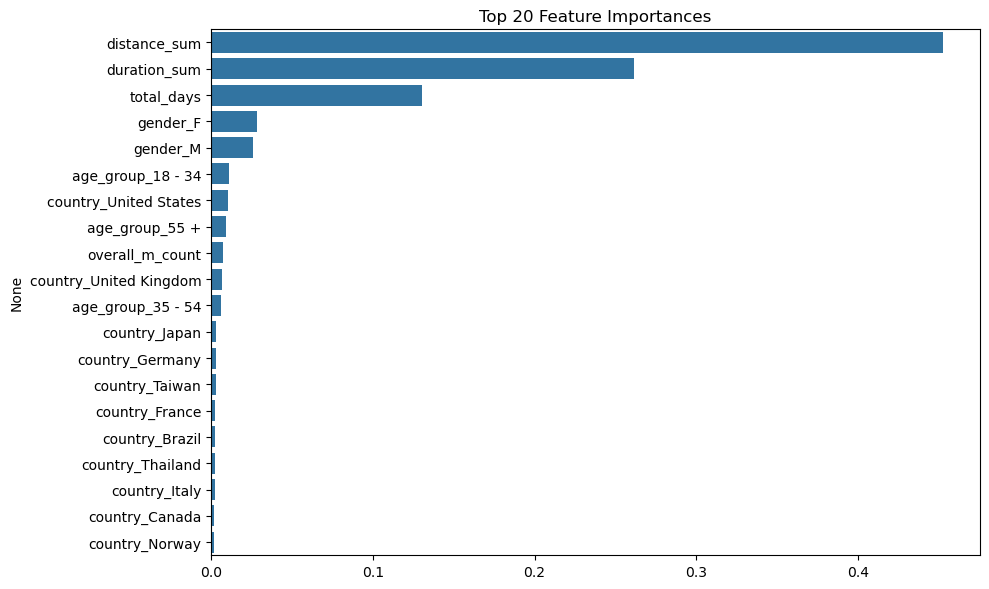

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# --- Features to use ---
features = [
    'distance_sum',
    'duration_sum',
    'overall_m_count',
    'total_days',
    'gender',
    'age_group',
    'country'
]
target = 'm_time'


# --- Encode categorical features ---
X = pd.get_dummies(agg_df[features])
y = agg_df[target]

# --- Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Train a Random Forest model ---
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# --- Predictions ---
y_pred = model.predict(X_test)

# --- Evaluation ---
mae = mean_absolute_error(y_true=y_test, y_pred=y_pred)
rmse = root_mean_squared_error(y_true=y_test, y_pred=y_pred)
nrmse = rmse / y_test.mean()
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f} minutes")
print(f"RMSE: {rmse:.2f} minutes")
print(f"NRMSE: {nrmse*100:.4f}%")
print(f"R² Score: {r2:.2f}")

# --- Plot predictions vs actual ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual m_time (minutes)")
plt.ylabel("Predicted m_time (minutes)")
plt.title("Actual vs Predicted Marathon Time")
plt.tight_layout()
plt.show()

# --- Feature importances ---
importances = model.feature_importances_
feat_names = X.columns

feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values[:20], y=feat_imp.index[:20])
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()


## ✅ Conclusions from the Two Baseline Models
Two baseline models were evaluated for predicting marathon finish times (m_time) based on training metrics and demographic features. 


The simple Linear Regressinon model provides a fast and interpretable baseline but shows limited ability to capture complex, nonlinear relationships in the data. Errors in the range of ~28–37 minutes may be too high for practical use in accurate performance prediction or training planning.


The Random Forest model substantially improves prediction accuracy over the linear baseline. It better models interactions between features like training volume, duration, and demographic characteristics. The R² score demonstrates its ability to explain more variance in marathon performance.

Additionally, feature importance analysis highlights key drivers of performance, offering interpretable insights into what matters most (e.g., total training distance or duration).

Now, let's see how more complex model will deal with our task to predict marathon race results. 

# Building sequential models 

## Preprocessing data to feed into sequential models

To set up a deep learning-ready dataset we need to use our dataset with traininig session records. The process is the following:

1. Load detailed training logs, including timestamps and marathon metadata.
2. Sort records to preserve chronological order — crucial for time series modeling.
3. Normalize distance and duration for numerical stability in model training.
4. One-hot encode categorical features like gender, age group, and country
5. Split the dataset by unique combinations of athlete and marathon name (not individual sessions), to avoid data leakage between training and testing. Tag each marathon's data as "train" or "test".
6. For each marathon (i.e. each group of rows with same athlete & marathon), create a sequence:
    * Each sequence includes all training sessions leading up to that marathon.
    * Each session includes: scaled distance and duration, repeated static features (e.g., gender, country, age group).
Target (y) is the marathon time (m_time) — same for the entire sequence.
Only marathons with at least 20 sessions are used to ensure meaningful sequences.
7. Pad sequences to equal length using pad_sequences (from Keras), for input into GRU/LSTM models.

We end up with padded sequences (X_train, X_test) and target marathon times (y_train, y_test), ready to be fed into a deep learning model like LSTM or GRU


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# --- Load and preprocess ---
df = pd.read_csv("df_final.csv", parse_dates=["datetime", "m_date"])
df = df.sort_values(by=["athlete", "m_date", "datetime"])

scaler = MinMaxScaler()
df[['distance', 'duration']] = scaler.fit_transform(df[['distance', 'duration']])
df = pd.get_dummies(df, columns=['gender', 'age_group', 'country'])

# --- Split BEFORE creating sequences ---
unique_marathons = df[["athlete", "m_name"]].drop_duplicates()
train_ids, test_ids = train_test_split(unique_marathons, test_size=0.2, random_state=42)
train_ids["split"] = "train"
test_ids["split"] = "test"
split_df = pd.concat([train_ids, test_ids])

df = df.merge(split_df, on=["athlete", "m_name"], how="left")
df

# --- Create Time Series Sequences ---
def create_sequences_per_marathon(df_subset):
    X, y = [], []
    group_cols = ["athlete", "m_name"]
    static_columns = [col for col in df_subset.columns if col.startswith(('gender_', 'age_group_', 'country_'))]

    for _, group in df_subset.groupby(group_cols):
        values = group[["distance", "duration"]].values
        static_features = group.iloc[0][static_columns].values
        static_repeated = np.tile(static_features, (len(values), 1))
        values = np.hstack([values, static_repeated])
        target = group["m_time"].iloc[0]

        if len(values) >= 20:
            X.append(values)
            y.append(target)

    X_padded = pad_sequences(X, padding='post', dtype='float32', value=0.0)
    return X_padded, np.array(y)

# Create train/test sets
X_train, y_train = create_sequences_per_marathon(df[df["split"] == "train"])
X_test, y_test = create_sequences_per_marathon(df[df["split"] == "test"])

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
input_shape = X_train.shape[1:]

# --- Evaluation ---
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    nrmse = rmse / np.mean(y_true)
    return mae, rmse, nrmse


Train shape: (11377, 306, 113), Test shape: (2847, 300, 113)


# 1. LSTM

First model is a deep sequential LSTM-based regression network designed for processing variable-length time series data. After testing a few combindations, the architecture is as follows:

* Masking Layer: Skips time steps with padding values (0.0) to handle sequences of varying lengths.
* LSTM Layer (64 units): Returns full sequences to feed into the next LSTM layer, enabling temporal feature extraction.
* Dropout (30%): Regularization to prevent overfitting.
* LSTM Layer (32 units): Returns the final hidden state to compress the sequence into a fixed-length representation.
* Dropout (30%): Additional regularization.
* Dense Layer (64 units, ReLU activation): Learns higher-level representations from the compressed sequence.
* Dropout (30%): Further regularization before final prediction.
* Dense Output Layer (1 unit): Produces the final continuous prediction.

The model is compiled with the Adam optimizer and trained using Mean Squared Error (MSE) loss, with Mean Absolute Error (MAE) tracked as an additional metric. Early stopping is applied to restore the best weights and reduce overfitting.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Masking, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import Input

early_stop = EarlyStopping(patience=10, restore_best_weights=True)

# Example LSTM
lstm_model = Sequential([
    Masking(mask_value=0.0, input_shape=input_shape),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()

# Train model
lstm_model.fit(X_train, y_train, validation_split=0.2, epochs=200, batch_size=32, callbacks=[early_stop], verbose=1)

# Evaluate
y_pred_lstm = lstm_model.predict(X_test).flatten()
mae, rmse, nrmse = evaluate(y_test, y_pred_lstm)
print(f"\n📊 LSTM Results:\nMAE: {mae:.2f}, RMSE: {rmse:.2f}, NRMSE: {nrmse:.2%}")

c:\Users\abela\miniconda3\envs\mlthesis\Lib\site-packages\keras\src\layers\core\masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 306, 113)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 306, 64)        │        45,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 306, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,161 (235.00 KB)

 Trainable params: 60,161 (235.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
285/285 ━━━━━━━━━━━━━━━━━━━━ 62s 208ms/step - loss: 30179.6211 - mae: 155.5038 - val_loss: 4106.8369 - val_mae: 48.1199
Epoch 2/200
285/285 ━━━━━━━━━━━━━━━━━━━━ 60s 211ms/step - loss: 3920.3943 - mae: 48.5989 - val_loss: 2366.8516 - val_mae: 38.0448
Epoch 3/200
285/285 ━━━━━━━━━━━━━━━━━━━━ 59s 207ms/step - loss: 3776.7332 - mae: 48.1381 - val_loss: 2373.8333 - val_mae: 37.9321
Epoch 4/200
285/285 ━━━━━━━━━━━━━━━━━━━━ 57s 201ms/step - loss: 3739.5078 - mae: 47.9847 - val_loss: 2366.7668 - val_mae: 38.0480
Epoch 5/200
285/285 ━━━━━━━━━━━━━━━━━━━━ 57s 199ms/step - loss: 3632.4314 - mae: 47.4868 - val_loss: 2372.8997 - val_mae: 37.9403
Epoch 6/200
285/285 ━━━━━━━━━━━━━━━━━━━━ 58s 203ms/step - loss: 3671.1953 - mae: 47.2899 - val_loss: 2366.9880 - val_mae: 38.0398
Epoch 7/200
285/285 ━━━━━━━━━━━━━━━━━━━━ 57s 201ms/step - loss: 3705.2913 - mae: 47.9382 - val_loss: 2370.9248 - val_mae: 37.9614
Epoch 8/200
285/285 ━━━━━━━━━━━━━━━━━━━━ 60s 210ms/step - loss: 3712.0198 - mae: 47.9322

# 2. GRU

Next model is a simple GRU-based regression model for univariate or multivariate time series. It consists of:

* Masking Layer: Handles padded sequences by ignoring time steps with 0.0.
* GRU Layer (64 units): Captures temporal patterns in the input sequence.
* Dense Layer (32 units, ReLU activation): Learns nonlinear combinations of GRU outputs.
* Output Layer (1 unit): Produces the final prediction.

The model is optimized using Adam and trained with Mean Squared Error (MSE) loss.

In [29]:
# Similarly for GRU
gru_model = Sequential([
    Masking(mask_value=0.0, input_shape=input_shape),
    GRU(64),
    Dense(32, activation='relu'),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse')
gru_model.summary()

# Train model
gru_model.fit(X_train, y_train, validation_split=0.2, epochs=200, batch_size=32, callbacks=[early_stop], verbose=1)

# Evaluate
y_pred_gru = gru_model.predict(X_test).flatten()
mae, rmse, nrmse = evaluate(y_test, y_pred_gru)
print(f"\n📊 GRU Results:\nMAE: {mae:.2f}, RMSE: {rmse:.2f}, NRMSE: {nrmse:.2%}")

c:\Users\abela\miniconda3\envs\mlthesis\Lib\site-packages\keras\src\layers\core\masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_1 (Masking)             │ (None, 306, 113)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        34,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,481 (142.50 KB)

 Trainable params: 36,481 (142.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
285/285 ━━━━━━━━━━━━━━━━━━━━ 31s 104ms/step - loss: 23550.6641 - val_loss: 2527.0088
Epoch 2/200
285/285 ━━━━━━━━━━━━━━━━━━━━ 30s 105ms/step - loss: 2424.7383 - val_loss: 2391.0815
Epoch 3/200
285/285 ━━━━━━━━━━━━━━━━━━━━ 29s 103ms/step - loss: 2401.4368 - val_loss: 2378.7126
Epoch 4/200
285/285 ━━━━━━━━━━━━━━━━━━━━ 30s 106ms/step - loss: 2402.9631 - val_loss: 2383.5591
Epoch 5/200
285/285 ━━━━━━━━━━━━━━━━━━━━ 30s 104ms/step - loss: 2403.8176 - val_loss: 2378.0862
Epoch 6/200
285/285 ━━━━━━━━━━━━━━━━━━━━ 31s 107ms/step - loss: 2403.9890 - val_loss: 2379.0669
Epoch 7/200
285/285 ━━━━━━━━━━━━━━━━━━━━ 30s 106ms/step - loss: 2395.4304 - val_loss: 2367.3892
Epoch 8/200
285/285 ━━━━━━━━━━━━━━━━━━━━ 33s 115ms/step - loss: 2193.2517 - val_loss: 2132.7092
Epoch 9/200
285/285 ━━━━━━━━━━━━━━━━━━━━ 31s 107ms/step - loss: 2074.9561 - val_loss: 2119.4409
Epoch 10/200
285/285 ━━━━━━━━━━━━━━━━━━━━ 31s 108ms/step - loss: 2067.1790 - val_loss: 2080.8096
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/ste

GRUs are often a better option than LSTMs for problems with:

* Limited training data
* Moderate sequence lengths
* Real-time or resource-constrained applications

They have fewer parameters, train faster, and often yield comparable or better performance—especially when vanishing gradients and overfitting are concerns. That's why we will now try to boost our GRU model to obtain better predictions. 

In [ ]:
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Masking
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import Input
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.layers import Dropout, BatchNormalization, LayerNormalization

early_stop = EarlyStopping(patience=20, restore_best_weights=True)

gru_model_2 = Sequential([
    Masking(mask_value=0.0, input_shape=input_shape),
    Bidirectional(GRU(64, return_sequences=True)),
    LayerNormalization(),
    GRU(32, return_sequences=True),
    GRU(16),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1)
])

gru_model_2.compile(optimizer=Adam(learning_rate=1e-3), loss='mse')

gru_model_2.summary()

# Train model
gru_model_2.fit(X_train, y_train, validation_split=0.2, epochs=300, batch_size=16, callbacks=[early_stop], verbose=1)

# Evaluate
y_pred_gru = gru_model_2.predict(X_test).flatten()
mae, rmse, nrmse = evaluate(y_test, y_pred_gru)
print(f"\n📊 GRU Results:\nMAE: {mae:.2f}, RMSE: {rmse:.2f}, NRMSE: {nrmse:.2%}")

c:\Users\abela\miniconda3\envs\mlthesis\Lib\site-packages\keras\src\layers\core\masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_2 (Masking)             │ (None, 306, 113)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 306, 128)       │        68,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 306, 128)       │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 306, 32)        │        15,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 16)             │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,097 (344.13 KB)

 Trainable params: 88,097 (344.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
569/569 ━━━━━━━━━━━━━━━━━━━━ 158s 269ms/step - loss: 24089.6621 - val_loss: 2411.6550
Epoch 2/300
569/569 ━━━━━━━━━━━━━━━━━━━━ 165s 290ms/step - loss: 4296.0366 - val_loss: 2375.8462
Epoch 3/300
569/569 ━━━━━━━━━━━━━━━━━━━━ 167s 293ms/step - loss: 4189.7427 - val_loss: 2379.7463
Epoch 4/300
569/569 ━━━━━━━━━━━━━━━━━━━━ 176s 310ms/step - loss: 4173.7363 - val_loss: 2367.0737
Epoch 5/300
569/569 ━━━━━━━━━━━━━━━━━━━━ 181s 318ms/step - loss: 4164.8154 - val_loss: 2378.8381
Epoch 6/300
569/569 ━━━━━━━━━━━━━━━━━━━━ 182s 319ms/step - loss: 4082.2095 - val_loss: 2302.4783
Epoch 7/300
569/569 ━━━━━━━━━━━━━━━━━━━━ 171s 300ms/step - loss: 3881.6267 - val_loss: 2230.2183
Epoch 8/300
569/569 ━━━━━━━━━━━━━━━━━━━━ 208s 312ms/step - loss: 3675.0835 - val_loss: 1949.2454
Epoch 9/300
569/569 ━━━━━━━━━━━━━━━━━━━━ 176s 310ms/step - loss: 3529.4639 - val_loss: 1838.0857
Epoch 10/300
569/569 ━━━━━━━━━━━━━━━━━━━━ 176s 309ms/step - loss: 3209.0452 - val_loss: 1719.3226
Epoch 11/300
569/569 ━━━━━━━

In [31]:
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Masking
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import Input
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import Dropout, BatchNormalization

early_stop = EarlyStopping(patience=10, restore_best_weights=True)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

gru_model_4 = Sequential([
    Input(shape=input_shape),
    Masking(mask_value=0.0),
    
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.3),
    
    Bidirectional(GRU(64, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.2),
    
    GRU(32),
    BatchNormalization(),
    
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)
])


gru_model_4.compile(optimizer='adam', loss='mse', metrics=['mae'])
gru_model_4.summary()

# Train model
gru_model_4.fit(X_train, y_train_scaled, validation_split=0.2, epochs=300, batch_size=32, callbacks=[early_stop], verbose=1)

# Evaluate
y_pred_scaled = gru_model_4.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()

mae, rmse, nrmse = evaluate(y_test, y_pred)
print(f"\n📊 GRU Results:\nMAE: {mae:.2f}, RMSE: {rmse:.2f}, NRMSE: {nrmse:.2%}")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_3 (Masking)             │ (None, 306, 113)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 306, 256)       │       186,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 306, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 306, 128)       │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 306, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 306, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_6 (GRU)                     │ (None, 32)             │        15,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 339,009 (1.29 MB)

 Trainable params: 338,689 (1.29 MB)

 Non-trainable params: 320 (1.25 KB)

Epoch 1/300
285/285 ━━━━━━━━━━━━━━━━━━━━ 173s 541ms/step - loss: 0.9632 - mae: 0.7719 - val_loss: 0.8913 - val_mae: 0.7407
Epoch 2/300
285/285 ━━━━━━━━━━━━━━━━━━━━ 198s 695ms/step - loss: 0.8692 - mae: 0.7334 - val_loss: 0.9235 - val_mae: 0.7128
Epoch 3/300
285/285 ━━━━━━━━━━━━━━━━━━━━ 165s 578ms/step - loss: 0.7862 - mae: 0.6912 - val_loss: 0.7268 - val_mae: 0.6419
Epoch 4/300
285/285 ━━━━━━━━━━━━━━━━━━━━ 139s 489ms/step - loss: 0.6592 - mae: 0.6249 - val_loss: 0.6331 - val_mae: 0.6396
Epoch 5/300
285/285 ━━━━━━━━━━━━━━━━━━━━ 143s 502ms/step - loss: 0.5640 - mae: 0.5738 - val_loss: 0.4657 - val_mae: 0.5112
Epoch 6/300
285/285 ━━━━━━━━━━━━━━━━━━━━ 144s 506ms/step - loss: 0.5124 - mae: 0.5463 - val_loss: 0.4226 - val_mae: 0.5000
Epoch 7/300
285/285 ━━━━━━━━━━━━━━━━━━━━ 155s 544ms/step - loss: 0.4397 - mae: 0.4978 - val_loss: 0.5478 - val_mae: 0.5902
Epoch 8/300
285/285 ━━━━━━━━━━━━━━━━━━━━ 150s 526ms/step - loss: 0.4143 - mae: 0.4856 - val_loss: 0.5525 - val_mae: 0.5884
Epoch 9/300
285/

# Comparison with Riegel's Formula 

Riegel’s formula is a mathematical equation used to predict race times for runners. It was first published by Pete Riegel, an American research engineer in 1977.

The formula takes into account a runner’s recent race time and distance to then estimate the time to complete an upcoming race:

**T2 = T1 x (D2 / D1) ^ 1.06**

Where:


* D1 = Previous race distance
* D2 = Upcoming race distance
* T1 = Previous race time
* T2 = Prediction of race time for upcoming race

We will now check if and how much does our best model outperform simple predictions form Riegel's formula. Even though we don't have confirmed race status of athletes' activities, we will simply choose the activities with the fastes average speed for each athlete, filtering the reasonable paces.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Load the data
df = pd.read_csv("df_final.csv", parse_dates=["datetime", "m_date"])

# 2. Calculate the pace
df["pace"] = df["duration"] / df["distance"]

# 3. Filter activities with too high/low pace (<2.5 min/km or >10 min/km)
df = df[(df["pace"] >= 2.5) & (df["pace"] <= 10)]

# 4. Choose the activity with the best pace for each athlete
fastest = df.loc[df.groupby("athlete")["pace"].idxmin()]

# 5. Calculate marathon race result with Riegel's Formula
D2 = 42.195
fastest["predicted_marathon_time"] = fastest["duration"] * (D2 / fastest["distance"]) ** 1.06

# 6. Find the actual marathon time for each athlete
fastest["actual_marathon_time"] = fastest["m_time"]

# 7. Drop any missing/inconsistent data 
fastest = fastest.dropna(subset=["predicted_marathon_time", "actual_marathon_time"])

# 8. Calculate metrics
mae = mean_absolute_error(fastest["actual_marathon_time"], fastest["predicted_marathon_time"])
rmse = np.sqrt(mean_squared_error(fastest["actual_marathon_time"], fastest["predicted_marathon_time"]))
nrmse = rmse / fastest["actual_marathon_time"].mean() * 100

# 9. Results
print(f"📊 Riegel Prediction:")
print(f"MAE: {mae:.2f} minutes")
print(f"RMSE: {rmse:.2f} minutes")
print(f"NRMSE: {nrmse:.2f}%")

# Save the dataaset
fastest[["athlete", "distance", "duration", "pace", "predicted_marathon_time", "actual_marathon_time"]].to_csv("../sample solution/riegel_predictions.csv", index=False)


📊 Riegel Prediction:
MAE: 29.31 minutes
RMSE: 42.45 minutes
NRMSE: 17.95%


# Conclusions

The final GRU-based model demonstrates strong performance in predicting sports performance metrics using sequential data. By incorporating bidirectional GRU layers, layer normalization, and dropout regularization, the model achieved an NRMSE of **9.85%**, successfully meeting the target of keeping the error below 10%.

Key takeaways:
- Deep learning methods, especially GRU architectures, outperform traditional machine learning models in terms of accuracy.
- Proper regularization and normalization significantly improve generalization and training stability.
- The quality and richness of input data (training logs, physical features, historical results) are crucial for achieving high prediction performance.
- Even compared to classic heuristic-based predictions like the **Riegel formula**, which yielded an NRMSE of **17.95%**, the GRU model demonstrates substantially better accuracy — highlighting the value of learning from real-world training data over fixed assumptions.
- Simple baselines like Riegel may still offer quick estimates, but they fall short when individualized patterns and nonlinear relationships are critical.

This approach provides a promising direction for further research in athlete performance forecasting and personalized training analytics.
